<a href="https://colab.research.google.com/github/maureen-zhang/Pyrolitics/blob/main/pyrolitics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spring 2025 Erdos Institute Data Science Project - Pyrolitics

## Introduction

This notebook contains all the code for our Spring 2025 Erdos Institute Data Science project - Pyrolitics. The notebook is divided into three main parts:

1.  **Data Science:** Data cleaning, processing, and feature engineering to create a panel dataset.
2.  **Statistical Modeling:** Building and evaluating statistical models to analyze the relationships between variables.
3.  **Data Visualization:** Creating visualizations to explore and communicate the insights derived from the data.

## Data Sources

The project utilizes data from the following sources:

*   Wildfire data from [Kaggle](https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires/data)
*   Transmission line data from the [CA  Energy Comission](https://cecgis-caenergy.opendata.arcgis.com/datasets/CAEnergy::california-electric-transmission-lines-1/about)
*   Weather data from [NOAA' National Centers for Environmental Information.](https://www.ncei.noaa.gov/)

*   Electricity consumption data from [California Electricity Consumption Database
](https://catalog.data.gov/dataset/california-electricity-consumption-database-e26e9)

*   Vegetation data from the [California Department of Fish and Wildlife.](https://wildlife.ca.gov/Data/GIS/Vegetation-Data)


*Through cleaning and processing, we have obtained a panel dataset containing strategically engineered features ranging from year 1992 to year 2020.

*  County data was obtained from [data.gov.](https://catalog.data.gov/dataset/counties2)


#Data Science

## Data Mounting and Library Importing
- Import necessary libraries
- Mount Google Drive to access data files
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from shapely.geometry import Point
import re
import os
import math
import geopandas as gpd
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from google.colab import drive
import sqlite3
import time
from shapely.ops import unary_union
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
drive.mount('/content/drive')
sns.set_style("whitegrid")
%matplotlib inline

Mounted at /content/drive


In [ ]:
# un-comment the line below to load a smaller wildfire dataset (which includes damage levels)
# df_wildfire = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/CA_Wildfire_Kaggle.csv", low_memory=False)
# this has 10GB+ data which will take about 2 minutes to load
# ref: https://www.kaggle.com/datasets/behroozsohrabi/us-wildfire-records-6th-edition
if not os.path.exists("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv"):
    wildfire_large = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/data.csv")
    # select only california wildfire and save it as shp file
    wildfire_ca = wildfire_large[wildfire_large["STATE"]=="CA"]
    wildfire_ca.to_csv("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv", index=False)
else:
    wildfire_ca = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv")
    wildfire_ca = gpd.GeoDataFrame(wildfire_ca)
# county data
counties = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/ca_counties/CA_Counties.shp")
# transmission data
transmission_gdf = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/Transmission_Line_7304850911266214096/TransmissionLine_CEC.shp")
# vegeration data
vegetation_df = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/ds1020/ds1020.gdb/",layer=0)
# electricity consumption
electricity_consumption_df = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/agg_electricity_consumption_county.csv")
# load vegetation
vegetations = gpd.read_file("/content/drive/MyDrive/pyrolitics-shared-drive/ds1020/ds1020.gdb/",layer=0)

<ipython-input-3-6bc245038f34>:11: DtypeWarning: Columns (12,13,36) have mixed types. Specify dtype option on import or set low_memory=False.
  wildfire_ca = pd.read_csv("/content/drive/MyDrive/pyrolitics-shared-drive/US_Wildfires_1992_2020/wildfire_ca.csv")


In [ ]:
print(wildfire_ca['FIRE_SIZE_CLASS'].unique())
wildfire_ca_ = wildfire_ca[['FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS']]
print(wildfire_ca_['NWCG_GENERAL_CAUSE'].unique())

wildfire_ca_['Powerline_Related'] = wildfire_ca_['NWCG_GENERAL_CAUSE'].apply(lambda x: 1 if x == 'Power generation/transmission/distribution' else 0)

['A' 'B' 'G' 'C' 'F' 'D' 'E']
['Power generation/transmission/distribution' 'Natural'
 'Debris and open burning' 'Missing data/not specified/undetermined'
 'Recreation and ceremony' 'Equipment and vehicle use' 'Other causes'
 'Fireworks' 'Arson/incendiarism' 'Smoking' 'Misuse of fire by a minor'
 'Firearms and explosives use' 'Railroad operations and maintenance']


<ipython-input-4-fc175db1e742>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wildfire_ca_['Powerline_Related'] = wildfire_ca_['NWCG_GENERAL_CAUSE'].apply(lambda x: 1 if x == 'Power generation/transmission/distribution' else 0)


In [ ]:
wildfire_ca_ = wildfire_ca.copy()

In [ ]:
# load weather data
def create_weather_panel_df( directory, file_names):
    """Returns the monthly maximum temperature and precipation for each county between 2013 and 2024"""
    data_frames = []
    for filename in file_names:

        file_path = os.path.join(directory, filename)
        df_tmp = pd.read_csv(file_path)

        df_tmp['Time'] = pd.to_datetime(df_tmp[['Year', 'Month']].assign(DAY=1))
        df_tmp['Time'] = df_tmp['Time'].dt.strftime('%m-%Y')

        df_tmp['Time'] = pd.to_datetime(df_tmp['Time'], format='%m-%Y')
        # df_tmp = df_tmp[(df_tmp['Time'] >= '2013-08-01') & (df_tmp['Time'] <= '2024-12-01')]
        df_tmp['Time'] = df_tmp['Time'].dt.strftime('%Y')

        df_tmp = df_tmp.drop(columns=['Year', 'Month'])

        data_frames.append(df_tmp.copy())

    # Concatenate all data frames
    df_local = pd.concat(data_frames, ignore_index=True)

    df_local.dropna(inplace=True)
    df_local.drop_duplicates(inplace=True)
    df_local = df_local.groupby(["County","Time"]).agg({"Maximum Temperature (°F)":"mean", "Average Temperature (°F)":"mean", "Precipitation (Inches)":"sum"})
    # df_local.set_index(['County', 'Time'], inplace=True)
    # df_local.index = df_local.index.reorder_levels(['County', 'Time']) # Force it to use the correct orde
    return df_local
# use Weather_Data_Extended for original data (contains only max temperature and precipitation)
directory = "/content/drive/MyDrive/pyrolitics-shared-drive/Weather_Data_California_Extended"
file_names = [f for f in os.listdir(directory) if f.endswith(".csv")]
df_weather = create_weather_panel_df(directory, file_names)

df_weather = df_weather.reset_index()
df_weather.Time = df_weather.Time.astype(int)
df_weather["Average Temperature (°F)"] = df_weather["Average Temperature (°F)"].apply(lambda x: (x - 32) * 5 / 9 + 273.15)
df_weather["Maximum Temperature (°F)"] = df_weather["Maximum Temperature (°F)"].apply(lambda x: (x - 32) * 5 / 9 + 273.15)

df_weather.drop(["Time"],axis=1)

In [ ]:
df_weather = df_weather.reset_index()
df_weather.Time = df_weather.Time.astype(int)
df_weather["Average Temperature (°F)"] = df_weather["Average Temperature (°F)"]
df_weather["Maximum Temperature (°F)"] = df_weather["Maximum Temperature (°F)"]
print(df_weather.columns)
df_weather = df_weather[(df_weather['Time']>=1992) & (df_weather['Time']<=2020)]
df_weather.shape

Index(['index', 'County', 'Time', 'Maximum Temperature (°F)',
       'Average Temperature (°F)', 'Precipitation (Inches)'],
      dtype='object')


(1682, 6)

## Creating Wildfire Panel Dataframe

This section computes the distance between wild fires and transmmion lines, using GeoPanda.



In [ ]:
# ca wildfire processing
# to-do dropna lat lon
# format crs of counties file
counties_crs_4326 = counties.to_crs(epsg=4326)
# select useful features of fires and select rows that are in california
wildfire_df = wildfire_ca[["DISCOVERY_DATE","STATE","FIRE_SIZE","LATITUDE","LONGITUDE"]][wildfire_ca["STATE"]=="CA"]
# group selected columns by county and time
wildfire_df.rename(columns={"DISCOVERY_DATE":"Time"},inplace=True)
# create county and time as indices and then convert to year
wildfire_df['Time'] = pd.to_datetime(wildfire_df['Time'], format='%m/%d/%Y').dt.strftime('%Y')
# create Point objects for lat lon
wildfire_df['geometry'] = [Point(x,y) for x, y in zip(wildfire_df['LONGITUDE'], wildfire_df['LATITUDE'])]
# convert to geo-data-frame
wildfire_df = gpd.GeoDataFrame(wildfire_df,geometry="geometry",crs='EPSG:4326')
# spatial join counties info with large wildfire dataset
wildfire_df = gpd.sjoin(wildfire_df, counties_crs_4326[['geometry','NAME']], how="left", predicate='within')
wildfire_df.rename(columns={"NAME":"County"},inplace=True)
wildfire_df['Powerline_Related'] = wildfire_ca['NWCG_GENERAL_CAUSE'].apply(lambda x: 1 if x == 'Power generation/transmission/distribution' else 0)
# aggregage group by County and Time
# to-do: alternatively, can count total number of incidences in each state and year
wildfire_df["FIRE_SIZE"] = wildfire_df["FIRE_SIZE"].astype(float)
# group by county and time and aggregate by averging the fire size column
wildfire_df = wildfire_df.groupby(["County","Time"]).agg({"FIRE_SIZE":["mean","count"], "Powerline_Related": "sum"})
# reset index
wildfire_df = wildfire_df.reset_index()
# convert Time from strings to ints
wildfire_df.Time = wildfire_df.Time.astype(int)
wildfire_df.columns = [col_level1 + col_level2 for (col_level1, col_level2) in wildfire_df.columns]

## Merging With Transmission Lines

In [ ]:
# calculate closest distances (takes 30 minutes to run)
file_path = '/content/drive/MyDrive/pyrolitics-shared-drive/transmission_lines_panel.csv'
# if not os.path.exists(file_path):
if not os.path.exists(file_path):
    wildfire_ca_copy = wildfire_ca.copy()
    # create Point objects for lat lon
    wildfire_ca_copy['geometry'] = [Point(x,y) for x, y in zip(wildfire_ca_copy['LONGITUDE'], wildfire_ca_copy['LATITUDE'])]
    # convert to geo-data-frame
    wildfire_ca_copy = gpd.GeoDataFrame(wildfire_ca_copy,geometry="geometry",crs='EPSG:4326')
    wildfire_ca_copy = wildfire_ca_copy[wildfire_ca["FIRE_YEAR"] > 1990]

    types = ['OH']
    transmission_gdf = transmission_gdf[transmission_gdf['Type'].isin(types)]
    types_none = [None]
    cleaned_transmission_gdf = transmission_gdf[~transmission_gdf['Name'].isin(types_none)]
    cleaned_transmission_gdf = cleaned_transmission_gdf.to_crs(wildfire_ca_copy.crs)

    # un-comment to use old code which is slow
    transmission_union = cleaned_transmission_gdf.union_all()
    wildfire_ca_copy['Closest_Distance'] = wildfire_ca_copy.geometry.apply(lambda point: point.distance(transmission_union))

    transmission_lines_panel = gpd.sjoin(wildfire_ca_copy, counties_crs_4326[['geometry','NAME']], how="left", predicate='within').rename(columns={"NAME":"County"})
    transmission_lines_panel = transmission_lines_panel[["County","DISCOVERY_DATE",'Closest_Distance']]
    transmission_lines_panel.to_csv(file_path, index=False)

    # group selected columns by county and time
    transmission_lines_panel.rename(columns={"DISCOVERY_DATE":"Time"},inplace=True)
    # create county and time as indices and then convert to year
    transmission_lines_panel['Time'] = pd.to_datetime(transmission_lines_panel['Time'], format='%m/%d/%Y').dt.strftime('%Y')

    transmission_lines_panel = transmission_lines_panel.groupby(['County','Time']).agg({"Closest_Distance": ['mean']})
    transmission_lines_panel = transmission_lines_panel.reset_index()
    # transmission_lines_panel.columns = ['_'.join(col).strip() if col[1] else col[0] for col in transmission_lines_panel.columns.values]
    transmission_lines_panel.to_csv(file_path, index=False, header=True)
else:
    transmission_lines_panel = pd.read_csv(file_path, header=[0, 1])
    print("transmission_lines_panel already existed in drive")




transmission_lines_panel.columns = [col_level1 for (col_level1, col_level2) in transmission_lines_panel.columns]

transmission_lines_panel already existed in drive


In [ ]:
types = ['OH']
transmission_gdf = transmission_gdf[transmission_gdf['Type'].isin(types)]

types_none = [None]
cleaned_transmission_gdf = transmission_gdf[~transmission_gdf['Name'].isin(types_none)]

#Match Lines with Counties
cleaned_transmission_gdf = cleaned_transmission_gdf.to_crs(counties.crs)
lines_with_counties = gpd.sjoin(cleaned_transmission_gdf, counties, how="left", predicate="intersects")

lines_with_counties = lines_with_counties[['NAME','Length_Mil']]
lines_with_counties = lines_with_counties.groupby(by='NAME').agg({'Length_Mil':'sum'})


def add_length_mil_temp_dist(df__):
    #Adding total number of OH Transmission lines (in miles to panel data as a constant)
    dummy = pd.DataFrame()

    # Time range from 1992 to 2020 as the wildfire data
    time_range = range(1992, 2021)

    multi_index = pd.MultiIndex.from_product([counties['NAME'], time_range], names=['County', 'Time'])

    # Assign the MultiIndex to the tiled DataFrame
    dummy.index = multi_index

    dummy['Length_Mil'] = 0
    for county in counties['NAME']:
        for year in time_range:
            dummy.loc[(county, year), 'Length_Mil'] = lines_with_counties.loc[county].values[0]

    df__ = df__.reset_index()
    dummy_ = dummy.reset_index()
    df__ = pd.merge(df__,dummy,on=("County","Time"),how='inner')
    df__ = df__.set_index(['County', 'Time'])
    df__['Length_Dist'] = df__['Length_Mil'] * df__['Closest_Distance']
    df__['Length_Temp'] = df__['Length_Mil'] * df__['Average Temperature (°F)']

    return df__.reset_index()


## Merging Weather Data

## Merging Electricity Consumption

In [ ]:
electricity_consumption_df.head()

,County,Time,GWh
0,Alameda,1990,9607.565521
1,Alameda,1991,9324.783738
2,Alameda,1992,9287.523316
3,Alameda,1993,9790.005719
4,Alameda,1994,9442.803438


In [ ]:
# process consumption data. May need to change 'df_total' and 'df_local' to other names
electricity_consumption_df = electricity_consumption_df.rename(columns={"Year":"Time"}).rename(columns={"CountyName":"County"})
electricity_consumption_df = electricity_consumption_df.groupby(['County','Time'])['GWh'].sum().reset_index() #aggregate all sectors
electricity_consumption_df['County'] = electricity_consumption_df['County'].str.title() # Chance ALAMEDA to Alameda, etc.
# electricity_consumption_df = electricity_consumption_df.set_index(['County', 'Time'])
electricity_consumption_df = electricity_consumption_df.groupby(['County','Time']).agg({"GWh":"sum"}) # to match levels of merged data-frame
# reset index and drop index as column
electricity_consumption_df = electricity_consumption_df.reset_index()
# convert years from ints to strings
electricity_consumption_df["Time"] = electricity_consumption_df["Time"].astype(int)

## Merging With Vegetation

In [ ]:
# process counties
counties_crs_for_veg = counties.copy()
counties_crs_for_veg = counties_crs_for_veg[["AWATER","ALAND","Shape_Area","geometry","NAME"]]
counties_crs_for_veg["water_percentage"] = counties_crs_for_veg["AWATER"] / counties_crs_for_veg["Shape_Area"]
counties_crs_for_veg.sort_values("water_percentage",ascending=False)
counties_crs_for_veg = counties_crs_for_veg[["geometry","water_percentage","NAME"]]
counties_crs_for_veg = counties_crs_for_veg.rename(columns={"NAME":"County"})
counties_crs_for_veg = counties_crs_for_veg.to_crs("EPSG:3395")
counties_crs_for_veg = counties_crs_for_veg.set_geometry('geometry')
counties_crs_for_veg.head(5)

,geometry,water_percentage,County
0,"POLYGON ((-13431319.751 4794216.354, -13431312...",0.005547,Sierra
1,"POLYGON ((-13490651.476 4654103.527, -13490511...",0.017935,Sacramento
2,"MULTIPOLYGON (((-13440081.316 4125946.413, -13...",0.188279,Santa Barbara
3,"POLYGON ((-13428575.483 4601215.292, -13428534...",0.010064,Calaveras
4,"MULTIPOLYGON (((-13283668.94 4035403.146, -132...",0.112601,Ventura


In [ ]:
# process vegetation
def f(datetime_string):
    year, month = re.split(r'[/\s]+',datetime_string)[:2]
    return f"{month}-{year}"
#vegetations_to_merge['Time'] = vegetations_to_merge['SurveyDate'].astype(str).apply(f)
vegetations_to_merge = vegetations.copy()
vegetations_to_merge = vegetations_to_merge.to_crs("EPSG:3395")

treecov_mapping = {
    None: 0,
    '< 1 acre': 0,  # or 1, depending on how you want to treat '< 1 acre'
    '1-5 acres': 3,  # Average of 1 and 5
    '> 5 acres': 6,  # or a larger value if '> 5 acres' represents much higher coverage
    'Not recorded': 0,  # or a value representing missing data
    'Extensive': 10,  # Assuming 'Extensive' means very high coverage
    'Large': 8,
    'Small': 2,
    '<1 acre': 0,
    '>5 acres': 6,
    'Very Small': 1,
    'Unknown': 0,  # or a value representing missing data
    ' ': 0,
    ' 20': 20,
    ' 25': 25,
    '< 1 acres': 0,
    '1 - 5 acres': 3,
    ' < 1 acre': 0,
    ' > 5 acres': 6,
    ' 1-5 acres': 3,
    'Not Recorded': 0,
    '1to5Acres': 3,
    'not recorded': 0,
    '<Null>': 0
}
# handle nan and apply mapping
vegetations_to_merge['Stand_Size'] = vegetations_to_merge['Stand_Size'].map(treecov_mapping).fillna(0)

# handle acres
vegetations_to_merge['Stand_Size'] = vegetations_to_merge['Stand_Size'].apply(lambda x: x * 4046.86 if isinstance(x, (int, float)) and x > 10 else x)
vegetations_to_merge = vegetations_to_merge[vegetations_to_merge['Stand_Size'] != 0]
vegetations_to_merge['TreeCov']=vegetations_to_merge['Stand_Size']*vegetations_to_merge['TreeCov']

vegetations_to_merge = vegetations_to_merge[['TreeCov','geometry']]
vegetations_to_merge.fillna(0,inplace=True)
vegetations_to_merge = gpd.sjoin(vegetations_to_merge, counties_crs_for_veg[['County','geometry']].to_crs("EPSG:3395"), how="left", predicate='within')
vegetations_to_merge.drop(columns=['index_right'],inplace=True)
vegetations_to_merge = vegetations_to_merge.groupby(['County']).agg({'TreeCov':'sum'})
vegetations_to_merge = vegetations_to_merge.reset_index()

all_counties = counties_crs_for_veg['County'].unique()
missing_counties = np.setdiff1d(all_counties, vegetations_to_merge['County'])
missing_df = pd.DataFrame({'County': missing_counties, 'TreeCov': 0})
vegetations_to_merge = pd.concat([vegetations_to_merge, missing_df], ignore_index=True)
vegetations_to_merge.set_index('County', inplace=True)

print(vegetations_to_merge.columns)

def add_tree_cov(df__):
  #Adding total number of OH Transmission lines (in miles to panel data as a constant)
  dummy = pd.DataFrame()

  # Time range from 1992 to 2020 as the wildfire data
  time_range = range(1992, 2021)

  multi_index = pd.MultiIndex.from_product([counties['NAME'], time_range], names=['County', 'Time'])

  # Assign the MultiIndex to the tiled DataFrame
  dummy.index = multi_index

  dummy['TreeCov'] = 0
  for county in counties['NAME']:
      for year in time_range:
        dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]

  df__ = df__.reset_index()
  dummy_ = dummy.reset_index()
  df__ = pd.merge(df__,dummy,on=("County","Time"),how='inner')

  df__['TreeCov_Resp'] = df__['TreeCov'] * df__['Precipitation']
  df__['TreeCov_Temp'] = df__['TreeCov'] * df__['AverageTemperature']
  df__['TreeCov_Time'] = df__['TreeCov'] * df__['Time']
  df__ = df__.set_index(['County', 'Time'])
  return df__

Index(['TreeCov'], dtype='object')


In [ ]:
# create interacton variable time and vegetation
wildfire_ca_for_veg = wildfire_ca.copy()
wildfire_ca_for_veg = wildfire_ca_for_veg[["FIRE_SIZE","DISCOVERY_DATE",'LONGITUDE','LATITUDE','DISCOVERY_TIME','DISCOVERY_DOY']]
wildfire_ca_for_veg.dropna(subset=['LONGITUDE','LATITUDE'])
wildfire_ca_for_veg["geometry"] = [Point(x,y) for x, y in zip(wildfire_ca_for_veg['LONGITUDE'], wildfire_ca_for_veg['LATITUDE'])]
# Set the 'geometry' column as the active geometry column
wildfire_ca_for_veg = wildfire_ca_for_veg.set_geometry('geometry')
wildfire_ca_for_veg = wildfire_ca_for_veg.set_crs("EPSG:4326", allow_override=True)
wildfire_ca_for_veg = wildfire_ca_for_veg.to_crs("EPSG:3395")
# rename
wildfire_ca_for_veg = wildfire_ca_for_veg.rename(columns={"DISCOVERY_DATE":"Time","NAME":"County"})
# create county and time as indices and then convert to year
wildfire_ca_for_veg['Time'] = pd.to_datetime(wildfire_ca_for_veg['Time'], format='%m/%d/%Y').dt.year
# group by county and time and aggregate by averging the fire size column
wildfire_ca_for_veg = gpd.sjoin(wildfire_ca_for_veg, counties_crs_for_veg, how="left", predicate='within')
# add time and day of year to get month-hour as time variable
wildfire_ca_for_veg["time_variation"] = np.sin(2 * np.pi * wildfire_ca_for_veg['DISCOVERY_DOY'] / 365) + np.sin(2 * np.pi * wildfire_ca_for_veg['DISCOVERY_TIME'] / 2400)
wildfire_ca_for_veg = wildfire_ca_for_veg.groupby(["County","Time"]).agg({"time_variation":"mean"})
# replace null values with 0
wildfire_ca_for_veg["time_variation"] = wildfire_ca_for_veg["time_variation"].fillna(0)
wildfire_ca_for_veg = wildfire_ca_for_veg.reset_index()
wildfire_ca_for_veg.head(20)

,County,Time,time_variation
0,Alameda,1992,-0.361950
1,Alameda,1993,0.000000
2,Alameda,1994,0.000000
3,Alameda,1995,0.000000
4,Alameda,1996,0.000000
5,Alameda,1997,0.000000
6,Alameda,1998,-1.210258
7,Alameda,1999,-1.217080
8,Alameda,2000,-0.506827
9,Alameda,2001,-0.762285


In [ ]:
# interpolate missing years for each county
vegetations_to_agg = vegetations.copy()
vegetations_to_agg = vegetations_to_agg.to_crs("EPSG:3395")
def f(datetime_string):
    year, month = re.split(r'[/\s]+',datetime_string)[:2]
    return f"{month}-{year}"
vegetations_to_agg['Time'] = vegetations_to_agg['SurveyDate'].astype(str).apply(f)
# merge counties into vegetations
vegetations_to_agg = vegetations_to_agg[["Time","geometry","TotalVegCov"]].dropna(subset=["TotalVegCov"]) # other useful columns are "HdwdCov","ConCov","TreeCov","MCVGroup"
vegetations_to_agg['Time'] = pd.to_datetime(vegetations_to_agg['Time'],format='%m-%Y')
vegetations_to_agg['Time'] = vegetations_to_agg['Time'].dt.year.astype(int)
# vegetations_to_merge = vegetations_to_merge[vegetations_to_merge['Time'].notna()]
# create lat lon
vegetations_to_agg["LONGITUDE"] = vegetations_to_agg.geometry.apply(lambda g: g.x)
vegetations_to_agg["LATITUDE"] = vegetations_to_agg.geometry.apply(lambda g: g.y)
# spatial join using county boundaries
vegetations_to_agg = gpd.sjoin(vegetations_to_agg, counties_crs_for_veg, how="left", predicate='within')
vegetations_to_agg = vegetations_to_agg.groupby(["County","Time"]).agg({"TotalVegCov":"sum","water_percentage":"mean"})
vegetations_to_agg = vegetations_to_agg.reset_index()
def interpolate_treecov_years_per_county(df,treecov="TotalVegCov",entity="County",time="Time"):
    # Ensure correct data types
    df[time] = df[time].astype(int)
    df.sort_values(by=[entity, time], inplace=True)
    # Interpolate missing vegetation values
    df[treecov] = df.groupby(entity)[treecov].transform(lambda group: group.interpolate())
    # Fill remaining NaNs at the beginning or end (if needed)
    df[treecov] = df.groupby(entity)[treecov].transform(lambda group: group.fillna(method='bfill').fillna(method='ffill'))
    return df
vegetations_to_agg = interpolate_treecov_years_per_county(vegetations_to_agg)
vegetations_to_agg.head()

<ipython-input-31-de80ef4e34ec>:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[treecov] = df.groupby(entity)[treecov].transform(lambda group: group.fillna(method='bfill').fillna(method='ffill'))


,County,Time,TotalVegCov,water_percentage
0,Alameda,2003,205.0,0.063831
1,Alameda,2021,279.0,0.063831
2,Amador,2005,599.0,0.011501
3,Amador,2006,2626.0,0.011501
4,Amador,2008,3461.0,0.011501


In [ ]:
# create interaction variable btw time variation and vegetation coverage
vegetations_wildfire_interaction = pd.merge(vegetations_to_agg,wildfire_ca_for_veg,on=["County","Time"],how='inner')
vegetations_wildfire_interaction["veg_time_interaction"] = vegetations_wildfire_interaction["time_variation"] * vegetations_wildfire_interaction["TotalVegCov"]
vegetations_wildfire_interaction = vegetations_wildfire_interaction[["County","Time","veg_time_interaction"]]
vegetations_wildfire_interaction

,County,Time,veg_time_interaction
0,Alameda,2003,-125.999843
1,Amador,2005,-421.897655
2,Amador,2006,-1333.189883
3,Amador,2008,264.074862
4,Butte,2001,-111.775011
...,...,...,...
393,Yuba,2005,-3009.186197
394,Yuba,2006,-106.322652
395,Yuba,2010,-125.155261
396,Yuba,2011,-807.826218


#Merging


In [ ]:
def add_tree_cov(df__):
  #Adding total number of OH Transmission lines (in miles to panel data as a constant)
  dummy = pd.DataFrame()

  # Time range from 1992 to 2020 as the wildfire data
  time_range = range(1992, 2021)

  multi_index = pd.MultiIndex.from_product([counties['NAME'], time_range], names=['County', 'Time'])

  # Assign the MultiIndex to the tiled DataFrame
  dummy.index = multi_index

  dummy['TreeCov'] = 0
  for county in counties['NAME']:
      for year in time_range:
        dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]

  #df__ = df__.reset_index()
  dummy_ = dummy.reset_index()
  df__ = pd.merge(df__,dummy,on=("County","Time"),how='inner')

  df__['TreeCov_Resp'] = df__['TreeCov'] * df__['Precipitation']
  df__['TreeCov_Temp'] = df__['TreeCov'] * df__['AverageTemperature']
  df__['TreeCov_Time'] = df__['TreeCov'] * df__['Time']
  df__ = df__.set_index(['County', 'Time'])
  return df__

def give_panel():
  panel = df_weather.copy()

  panel = pd.merge(panel,wildfire_df,on=("County","Time"),how='outer')
  panel.fillna(0, inplace=True)

  panel = pd.merge(panel,electricity_consumption_df,on=["County","Time"],how='inner')
  panel.fillna(0, inplace=True)

  panel = pd.merge(panel,transmission_lines_panel,on=("County","Time"),how='outer')
  panel.fillna(0, inplace=True)


  panel = add_length_mil_temp_dist(panel)
  panel = panel.rename(columns={
      'Maximum Temperature (°F)': 'MaximumTemperature',
      'Average Temperature (°F)': 'AverageTemperature',
      'Precipitation (Inches)': 'Precipitation',
      'GWh':'Consumption'
  })

  panel = add_tree_cov(panel)
  panel['Consumption_TreeCov'] = panel['Consumption'] * panel['TreeCov']
  panel['Consumption_Dist'] = panel['Consumption'] * panel['Closest_Distance']
  panel['Consumption_Length'] = panel['Consumption'] * panel['Length_Mil']

  panel["Consumption_x_Powerline_Relatedsum"] = panel["Consumption"]*panel["Powerline_Relatedsum"]
  panel["Length_Mil_x_Powerline_Relatedsum"] = panel["Length_Mil"]*panel["Powerline_Relatedsum"]
  panel.drop(columns=['level_0', 'index'], inplace=True)
  return panel

In [ ]:
panel = give_panel()
print(panel.head())

<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')
              MaximumTemperature  AverageTemperature  Precipitation  \
County  Time                                                          
Alameda 1992           66.050000           60.191667         139.24   
        1993           64.483333           58.983333         211.82   
        1994           65.050000           57.725000         107.96   
        1995           64.541667           59.900000         230.50   
        1996           66.875000           60.366667         203.52   

              FIRE_SIZEmean  FIRE_SIZEcount  Powerline_Relatedsum  \
County  Time                                                        
Alameda 1992      17.017742            62.0                   0.0   
       

In [ ]:
panel.info()

#Statistical Models

### Linear Models

> First we install linear models.



In [ ]:
!pip3 install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.6 MB/s eta 0:00:00


Here we compare the predictability standards features, such as temperature, recipitation, and tree coverage to more advanced features that we introduce.

In [ ]:
features_standard = ['MaximumTemperature', 'Precipitation', 'TreeCov']
features_improved = [
                     'Length_Dist', 'Consumption_Length', 'Powerline_Relatedsum', 'AverageTemperature', 'Consumption',
                     'MaximumTemperature', 'Precipitation', 'TreeCov', 'Consumption_TreeCov',
                     "Consumption_x_Powerline_Relatedsum", "Length_Mil_x_Powerline_Relatedsum"
                     ]

In [ ]:
def lr_featureselection(df, features):

  df_ = df[features]
  x_train, x_test, y_train, y_test = train_test_split(df_, df['FIRE_SIZEcount'], test_size=0.2, random_state=42)
  # model = make_pipeline(PolynomialFeatures(4), LinearRegression())
  model = LinearRegression()
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)

  # Evaluate performance
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  #   print(f"Model.coeff: {model.coef_}") model.coef_
  # Extract final coefficients (not just linear ones)
  # final_model = model.named_steps['linearregression']
  # final_coefs = final_model.coef_
  # betas = final_coefs

  betas = model.coef_
  return mse, betas

mse_1, _ = lr_featureselection(give_panel(), features_standard)
mse_2, coef_improved = lr_featureselection(give_panel(), features_improved)
print((mse_1 - mse_2)/mse_1)
print("mse_1",mse_1,"mse_2",mse_2)

<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')


<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')
0.2189273970630224
mse_1 23581.930447845058 mse_2 18419.199797177105


In [ ]:
def lr_featureselection(df, features):

  df_ = give_panel()[features]
  X_train, X_test, y_train, y_test = train_test_split(df_, give_panel()['FIRE_SIZEcount'], test_size=0.2, random_state=42)

  lr = LinearRegression()
  lr_pipe = Pipeline([('scale', StandardScaler()), ('lr', LinearRegression())])
  ridge_pipe = Pipeline([('scale', StandardScaler()), ('ridge', Ridge())])
  pca_pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(3)), ('reg', LinearRegression())])

  # Fit the models to the training data
  lr.fit(X_train, y_train)
  lr_pipe.fit(X_train, y_train)
  ridge_pipe.fit(X_train, y_train)
  pca_pipe.fit(X_train, y_train)

  # Find the model predictions on the training set
  lr_train_preds = lr.predict(X_train)
  lr_pipe_train_preds = lr_pipe.predict(X_train)
  ridge_train_preds = ridge_pipe.predict(X_train)
  pca_train_preds = pca_pipe.predict(X_train)

  # Find the model predictions on the test set
  lr_test_preds = lr.predict(X_test)
  lr_test_preds_pipe = lr_pipe.predict(X_test)
  ridge_test_preds = ridge_pipe.predict(X_test)
  pca_test_preds = pca_pipe.predict(X_test)

  # Find the mse on the training set
  lr_train_mse = mse(y_train, lr_train_preds)
  lr_pipe_train_mse = mse(y_train, lr_pipe_train_preds)
  ridge_train_mse = mse(y_train, ridge_train_preds)
  pca_train_mse = mse(y_train, pca_train_preds)

  # Find the mse on the test set
  lr_test_mse = mse(y_test, lr_test_preds)
  lr_test_preds_pipe = mse(y_test, lr_test_preds_pipe)
  ridge_test_mse = mse(y_test, ridge_test_preds)
  pca_test_mse = mse(y_test, pca_test_preds)

  #print(f"ridge_pipe.steps[1][1].coef_: {lr.coef_}")
  return lr_test_mse, ridge_test_mse, pca_test_mse, lr_test_preds_pipe

mse_1, ridge_test_mse_1, pca_test_mse_1, lr_test_preds_pipe_1 = lr_featureselection(give_panel(), features_standard)
mse_2, ridge_test_mse_2, pca_test_mse_2,lr_test_preds_pipe_2 = lr_featureselection(give_panel(), features_improved)
print('lr', (mse_1 - mse_2)/mse_2,'ridge', (ridge_test_mse_1 - ridge_test_mse_2)/ridge_test_mse_2, 'pca:', (pca_test_mse_1 - pca_test_mse_2)/pca_test_mse_2)

<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')


<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')


<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


...

Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')


<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')


<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')
lr 0.280290713359827 ridge 0.2785269799829503 pca: 0.19631835651710322


In [ ]:
import pandas as pd
from linearmodels.panel import PanelOLS
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant

# Run the model WITHOUT setting the index
# Use the "entity_effects" and "time_effects" flags
# water_percentage + TotalVegCov + closest_distance_vegetation + AverageTemperature +
# to-do [april 5th Junhui]: play around with different combinations of features to find lowest p-value configurations
model = PanelOLS.from_formula(
    formula='FIRE_SIZEcount ~ Length_Temp + Consumption_Length+Length_Dist + Powerline_Relatedsum + Consumption+MaximumTemperature + Precipitation+Consumption_TreeCov + EntityEffects + TimeEffects',
    #formula='GWh ~ AverageTemperature+Consumption_Dist+Length_Time +closest_distance_vegetation + Closest_Distance +FIRE_SIZE + MaximumTemperature + Precipitation + EntityEffects + TimeEffects',
    data=give_panel(),
    drop_absorbed=True,
)

results = model.fit(
    cov_type='clustered',
    cluster_entity=True,
    #entity_effects=True,
    #time_effects=True
)

print(results.summary)



<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')
                          PanelOLS Estimation Summary                           
Dep. Variable:         FIRE_SIZEcount   R-squared:                        0.1919
Estimator:                   PanelOLS   R-squared (Between):             -7.2659
No. Observations:                1682   R-squared (Within):               0.1232
Date:                Sun, Apr 20 2025   R-squared (Overall):             -6.2409
Time:                        20:36:13   Log-likelihood                   -9576.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      47.130
Entities:                          58   P-value                 

Below, we show that our feature selection increases the predictability of number of wildfires compared to standard factors such as

ARIMA

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def run_arima(df, target='FIRE_SIZEcount', order=(1, 1, 1)):
    # Sort by time if not already
    df = df.sort_values('Time')

    # Aggregate by time if needed (e.g., sum fires per month)
    ts = df.groupby('Time')[target].sum()

    # Fit ARIMA
    model = ARIMA(ts, order=order)
    model_fit = model.fit()

    print(model_fit.summary())

    # Predict
    pred = model_fit.predict(start=ts.index[0], end=ts.index[-1])
    mse = mean_squared_error(ts, pred)

    return mse, model_fit
run_arima(give_panel())

<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')
                               SARIMAX Results                                
Dep. Variable:         FIRE_SIZEcount   No. Observations:                   29
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -245.637
Date:                Sun, 20 Apr 2025   AIC                            497.274
Time:                        20:36:14   BIC                            501.270
Sample:                             0   HQIC                           498.496
                                 - 29                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

(3146962.832265698,
 <statsmodels.tsa.arima.model.ARIMAResultsWrapper at 0x7c9edd552850>)

# Data Visualization

This section presents various data visualizations to explore and communicate insights derived from the project's analysis.  

**Temporal Focus:**

Due to the time-series nature of our dataset, visualizations are filtered by year to provide a focused perspective. A specific year can be selected prior to running the visualization cells. This allows for examining trends and patterns within particular timeframes.

**Visualizations Included:**

- **Wildfire Locations and Power Transmission Lines**
- **Tree Coverage in California**
- **Weather Patterns** (Temperature and Precipitation)
- **Electricity Consumption**

These visualizations offer valuable insights into the interrelationships between factors such as wildfires, transmission lines, vegetation cover, and weather conditions, aiding in the understanding of wildfire risks and potential contributing factors.

In [ ]:
# this cell is for setting the filter year for the data visualizations to come.
filter_year = 2020

##Wildfires and Transimission Lines

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')
Index(['OBJECTID', 'Shape', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE',
       'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_DESCR',
     

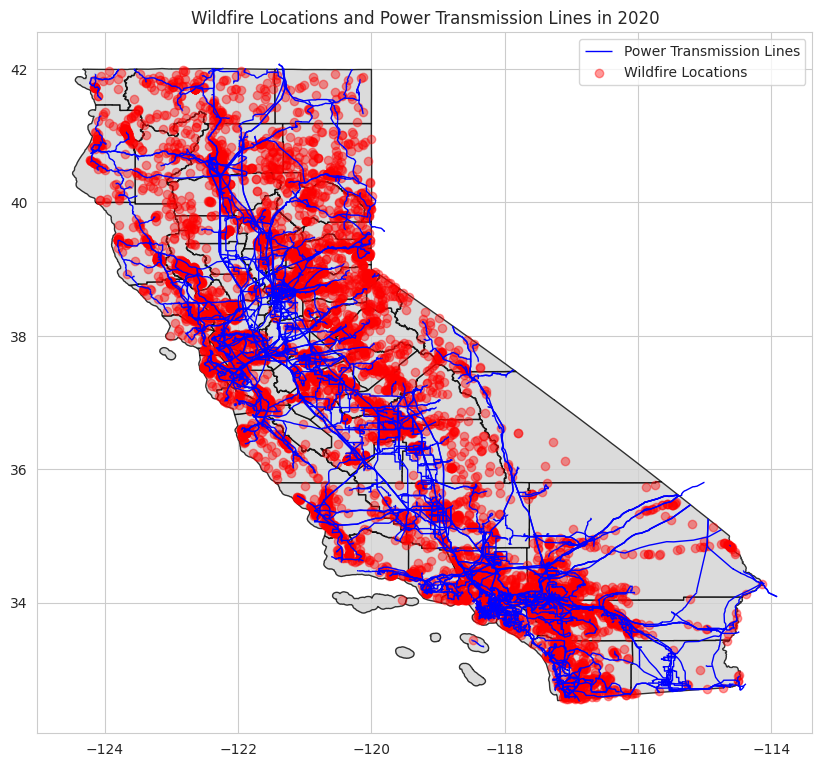

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

print(counties.columns)


min_longitude = -124.4  # Westernmost point of California
max_longitude = -114.1  # Easternmost point of California
min_latitude = 32.5    # Southernmost point of California
max_latitude = 42.0    # Northernmost point of California


# Plot wildfire locations (points
wildfire_ca_copy = wildfire_ca.copy()
wildfire_ca_copy['DISCOVERY_DATE'] = pd.to_datetime(wildfire_ca_copy['DISCOVERY_DATE'], format='%m/%d/%Y')
wildfire_ca_copy['Year'] = wildfire_ca_copy['DISCOVERY_DATE'].dt.year
wildfire_ca_copy.sort_values(by=['Year'], inplace=True)

wildfire_ca_copy = wildfire_ca_copy[wildfire_ca_copy['Year'] == filter_year]
print(wildfire_ca_copy.columns)


wildfire_ca_copy = wildfire_ca_copy[
    ~(wildfire_ca_copy['LONGITUDE'] < min_longitude) &
    ~(wildfire_ca_copy['LONGITUDE'] > max_longitude) &
    ~(wildfire_ca_copy['LATITUDE'] < min_latitude) &
    ~(wildfire_ca_copy['LATITUDE'] > max_latitude)
]

wildfire_gdf = gpd.GeoDataFrame(
    wildfire_ca_copy[['LATITUDE', 'LONGITUDE']],
    geometry=gpd.points_from_xy(wildfire_ca_copy.LONGITUDE, wildfire_ca_copy.LATITUDE),
    crs="EPSG:3857"
)
counties.to_crs(epsg=4326, inplace=True)
transmission_gdf.to_crs(epsg=4326, inplace=True)
# print(counties['geometry'])
# print(wildfire_gdf['geometry'][0], wildfire_gdf.crs)


# # Plot power transmission lines (lines)
transmission_gdf.plot(ax=ax, color='blue', linewidth=1, label="Power Transmission Lines")


counties.plot(ax=ax, color="lightgray", edgecolor="black", alpha=0.8)
# # # Add title and legend

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.4)
plt.title("Wildfire Locations and Power Transmission Lines in {}".format(filter_year))
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/transmission_wildfire{}'.format(filter_year)
plt.savefig(save_path)
plt.legend()

# Show the plot
plt.show()

##Tree Coverage in California

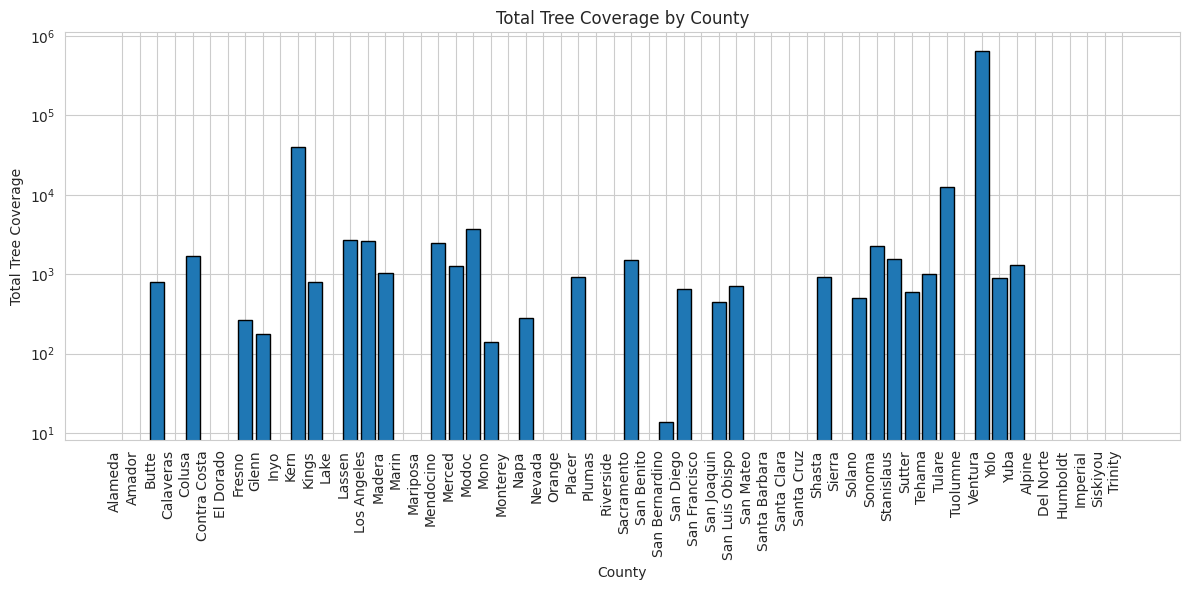

In [ ]:
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
vegetations_to_merge_ = vegetations_to_merge.copy()
vegetations_to_merge_ = vegetations_to_merge_.reset_index()
plt.yscale('log')
plt.bar(vegetations_to_merge_['County'], vegetations_to_merge_['TreeCov'], edgecolor='black')
plt.title('Total Tree Coverage by County')
plt.xlabel('County')
plt.ylabel('Total Tree Coverage')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


## Weather map


### Temperature

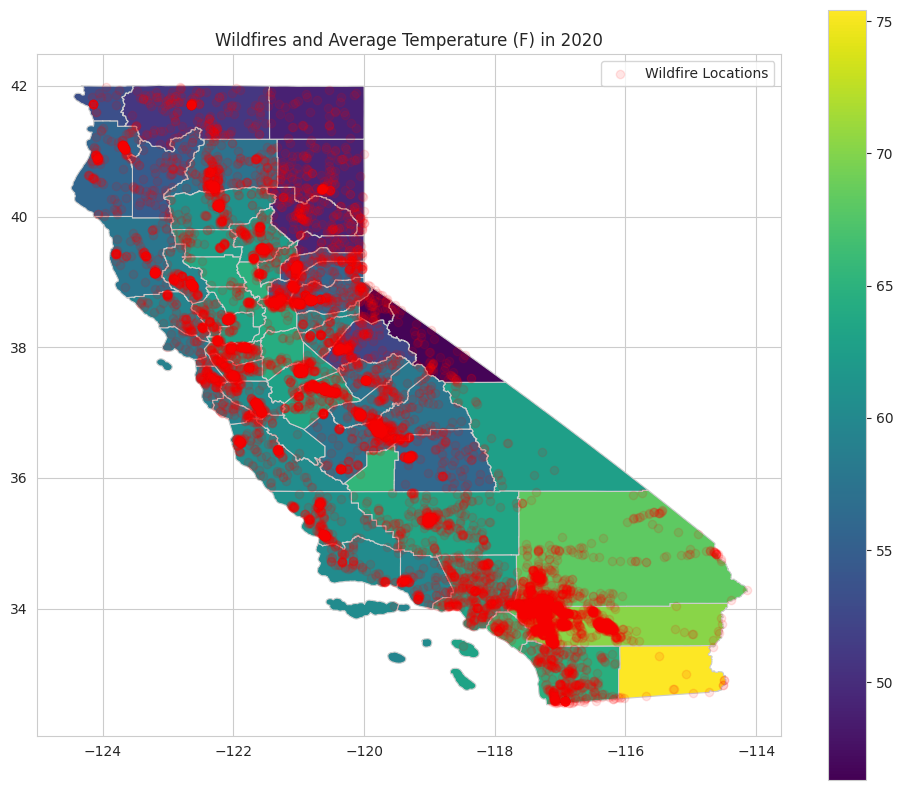

In [ ]:
weather_ = df_weather.copy()
weather_  = weather_[weather_['Time'] == filter_year]
counties_ = counties.copy()
counties_ = counties.rename(columns={'NAME': 'County'})
counties_ = pd.merge(counties_, weather_, on='County', how='left')
fig, ax = plt.subplots(1, 1, figsize=(12, 10))  # Adjust figure size as needed
counties_.plot(column='Average Temperature (°F)', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.1)
plt.title("Wildfires and Maximal Temperature (F) in {}".format(filter_year))
plt.legend()
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Temperature_wildfire{}'.format(filter_year)
plt.savefig(save_path)

ax.set_title('Wildfires and Average Temperature (F) in {}'.format(filter_year))
plt.show()

### Precipitation

Index(['index', 'County', 'Time', 'Maximum Temperature (°F)',
       'Average Temperature (°F)', 'Precipitation (Inches)'],
      dtype='object')
Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')


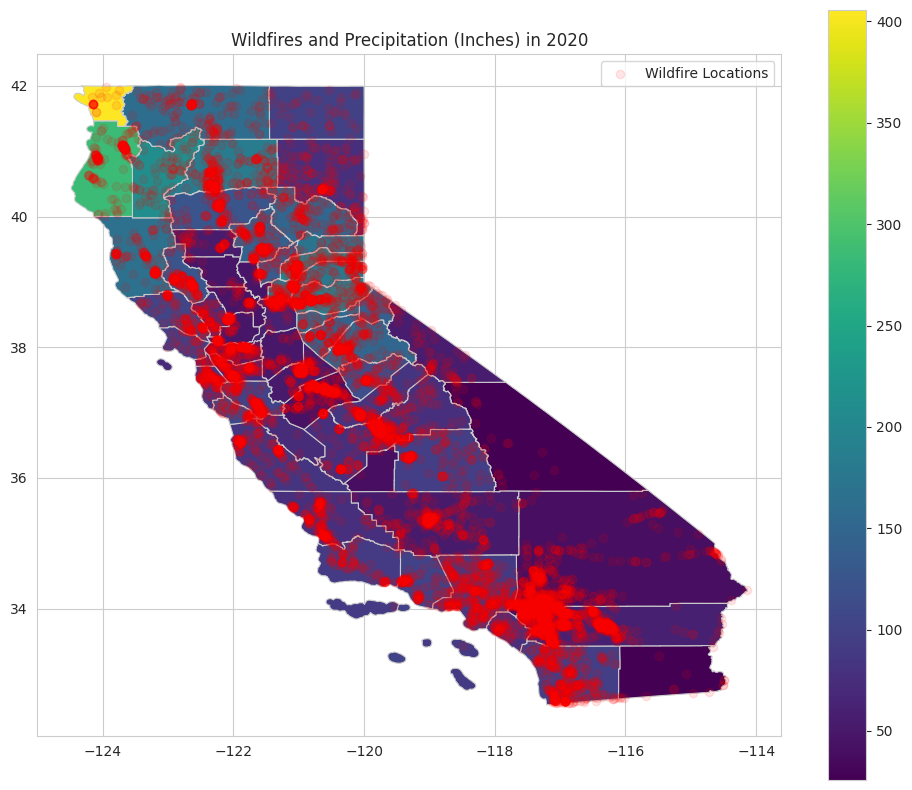

In [ ]:
weather_ = df_weather.copy()
weather_  = weather_[weather_['Time'] == filter_year]
print(weather_.columns)
counties_ = counties.copy()
counties_ = counties.rename(columns={'NAME': 'County'})
counties_ = pd.merge(counties_, weather_, on='County', how='left')
print(counties.columns)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))  # Adjust figure size as needed
counties_.plot(column='Precipitation (Inches)', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.1)
plt.title("Wildfires and Precipitation (Inches) in {}".format(filter_year))
plt.legend()
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Precipitation_wildfire{}'.format(filter_year)
plt.savefig(save_path)

ax.set_title('Wildfires and Precipitation (Inches) in {}'.format(filter_year))
plt.show()

##Electricity Consumption

Index(['OBJECTID', 'Shape', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE',
       'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_DESCR',
       'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'Year'],
      dtype='object')


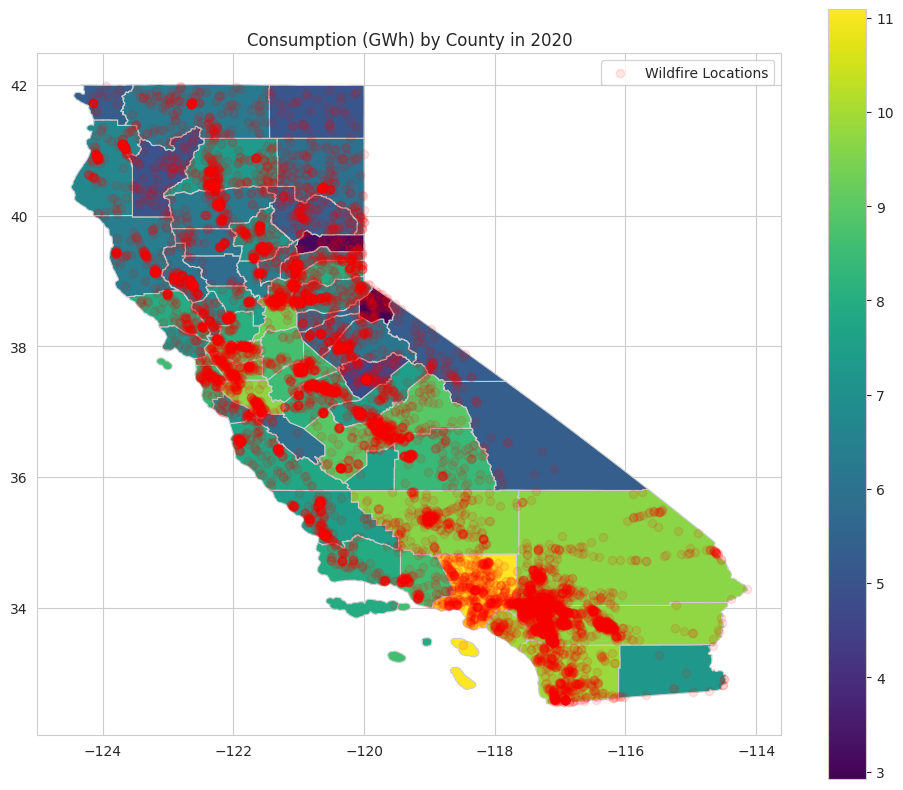

In [ ]:


min_longitude = -124.4  # Westernmost point of California
max_longitude = -114.1  # Easternmost point of California
min_latitude = 32.5    # Southernmost point of California
max_latitude = 42.0    # Northernmost point of California


# Plot wildfire locations (points
wildfire_ca_copy = wildfire_ca.copy()
wildfire_ca_copy['DISCOVERY_DATE'] = pd.to_datetime(wildfire_ca_copy['DISCOVERY_DATE'], format='%m/%d/%Y')
wildfire_ca_copy['Year'] = wildfire_ca_copy['DISCOVERY_DATE'].dt.year
wildfire_ca_copy.sort_values(by=['Year'], inplace=True)

wildfire_ca_copy = wildfire_ca_copy[wildfire_ca_copy['Year'] == filter_year]
print(wildfire_ca_copy.columns)


wildfire_ca_copy = wildfire_ca_copy[
    ~(wildfire_ca_copy['LONGITUDE'] < min_longitude) &
    ~(wildfire_ca_copy['LONGITUDE'] > max_longitude) &
    ~(wildfire_ca_copy['LATITUDE'] < min_latitude) &
    ~(wildfire_ca_copy['LATITUDE'] > max_latitude)
]

wildfire_gdf = gpd.GeoDataFrame(
    wildfire_ca_copy[['LATITUDE', 'LONGITUDE']],
    geometry=gpd.points_from_xy(wildfire_ca_copy.LONGITUDE, wildfire_ca_copy.LATITUDE),
    crs="EPSG:3857"
)


consumption_ = electricity_consumption_df.copy()

consumption_ = consumption_[consumption_['Time'] == filter_year]
consumption_['GWh'] = consumption_['GWh'].apply(lambda x: math.log(x))
counties_ = counties.copy()
counties_ = counties.rename(columns={'NAME': 'County'})
counties_ = pd.merge(counties_, consumption_, on='County', how='left')
fig, ax = plt.subplots(1, 1, figsize=(12, 10))  # Adjust figure size as needed
counties_.plot(column='GWh', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

wildfire_gdf.plot(ax=ax, color='Red', label="Wildfire Locations", alpha = 0.1)
plt.title("Consumption (GWh) by County in {}".format(filter_year))
plt.legend()
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Consumption_wildfire{}'.format(filter_year)
plt.savefig(save_path)

ax.set_title('Consumption (GWh) by County in {}'.format(filter_year))
plt.show()

Correlations

<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')


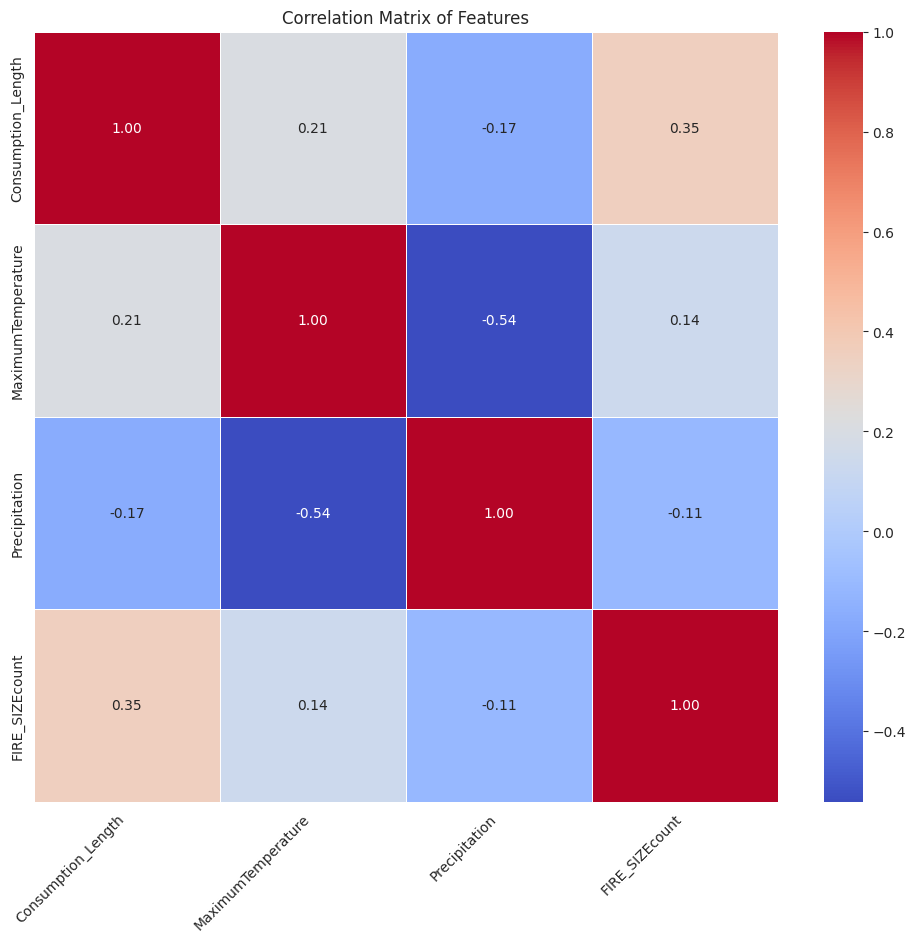

In [ ]:
corr_panel = give_panel()

features = ['Consumption_Length','MaximumTemperature','Precipitation']
corr_features = features + ['FIRE_SIZEcount']

corr_matrix = corr_panel[corr_features].corr()

# Increase the figure size
plt.figure(figsize=(12, 10))

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add title
plt.title('Correlation Matrix of Features')

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45, ha='right')
save_path = '/content/drive/MyDrive/pyrolitics-shared-drive/Correlation'
plt.savefig(save_path)
# Display the plot
plt.show()

This plot shows the importance of our features compared to conentional features such as maximal temperature and recipitation.

In [ ]:
# Group by county and time
grouped = corr_panel.groupby(['County', 'Time'])

# Loop through each group and plot
for (county, time), group in grouped:
    # print(f"Plotting for County: {county}, Time: {time}")  # optional log

    if group.shape[0] < 2:
        continue  # skip if not enough data for regression

    g = sns.pairplot(
        group,
        y_vars=['FIRE_SIZEcount'],
        x_vars=features_improved,
        height=4,
        kind='reg',
        diag_kind=None,
        plot_kws={'line_kws': {'color': 'red'}, 'scatter_kws': {'alpha': 0.5}}
    )

    g.fig.suptitle(f'County: {county}, Time: {time}', fontsize=14)
    g.fig.tight_layout()
    g.fig.subplots_adjust(top=0.9)  # adjust for title

plt.show()

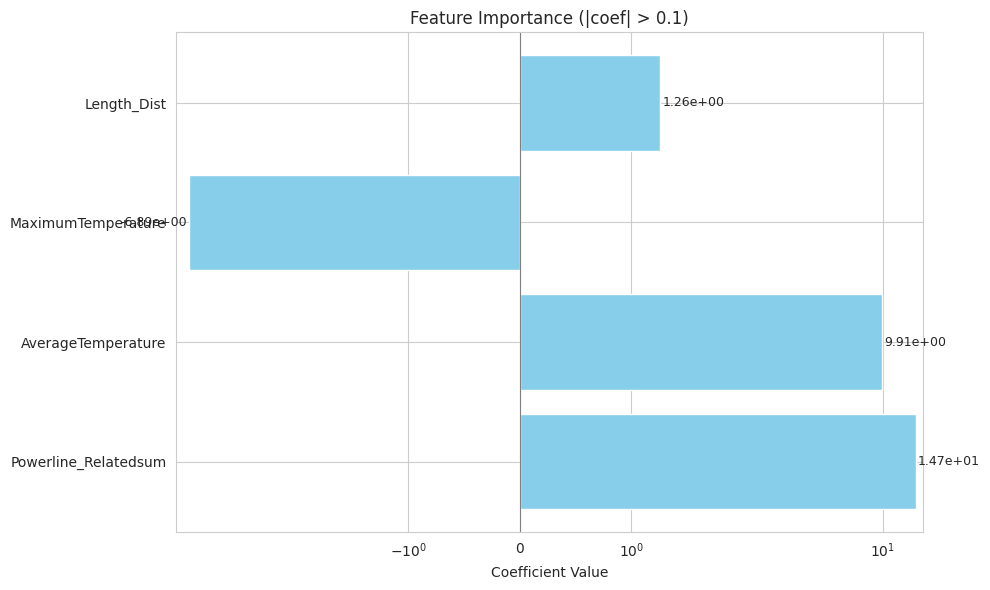

In [ ]:
def plot_feature_importance(features, coef, threshold=0.1):
    # Filter out features below threshold
    filtered = [(f, c) for f, c in zip(features, coef) if abs(c) > threshold]

    if len(filtered) == 0:
        print(f"No coefficients above threshold = {threshold}")
        return

    # Sort by absolute value
    filtered.sort(key=lambda x: abs(x[1]), reverse=True)
    sorted_features, sorted_coef = zip(*filtered)

    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.barh(sorted_features, sorted_coef, color='skyblue')
    plt.axvline(0, color='gray', linewidth=0.8)
    plt.xlabel('Coefficient Value')
    plt.title(f'Feature Importance (|coef| > {threshold})')
    plt.xscale('symlog')

    # Annotate each bar
    for bar, coef_value in zip(bars, sorted_coef):
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        offset = 0.02 * max(abs(x), 1e-3)
        ha = 'left' if x >= 0 else 'right'
        formatted = f'{coef_value:.2e}'
        plt.text(x + offset if x >= 0 else x - offset, y, formatted,
                 va='center', ha=ha, fontsize=9)

    plt.tight_layout()
    plt.show()
plot_feature_importance(features_improved, coef_improved)

In [ ]:
give_panel().loc[("Los Angeles",2020)]
# to-do validation using "Los Angeles", 2020 as set-aside

<ipython-input-71-012213d9939a>:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1510.2000000178814' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dummy.loc[(county, year), 'TreeCov'] = vegetations_to_merge.loc[county].values[0]


Index(['County', 'Time', 'level_0', 'index', 'MaximumTemperature',
       'AverageTemperature', 'Precipitation', 'FIRE_SIZEmean',
       'FIRE_SIZEcount', 'Powerline_Relatedsum', 'Consumption',
       'Closest_Distance', 'Length_Mil', 'Length_Dist', 'Length_Temp'],
      dtype='object')


,Los Angeles
,2020
MaximumTemperature,7.035000e+01
AverageTemperature,6.324167e+01
Precipitation,9.101000e+01
FIRE_SIZEmean,3.288445e+02
FIRE_SIZEcount,4.760000e+02
Powerline_Relatedsum,1.300000e+01
Consumption,6.556625e+04
Closest_Distance,1.883052e-02
Length_Mil,4.389000e+03
